In [9]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed data
processed_file = "../data/processed/daily_rainfall.csv"
df = pd.read_csv(processed_file)

# Quick look
df.head()


,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0


## Shape and Info

In [ ]:
print("Shape of the dataset:", df.shape)

print(df.info())

Shape of the dataset: (204876, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          204876 non-null  int64  
 1   date        204876 non-null  object 
 2   state_code  204876 non-null  int64  
 3   state_name  204876 non-null  object 
 4   actual      204876 non-null  float64
 5   rfs         199011 non-null  float64
 6   normal      193358 non-null  float64
 7   deviation   173855 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 12.5+ MB

 None


## Check missing values

In [22]:
print(df.isnull().sum())

id                0
date              0
state_code        0
state_name        0
actual            0
rfs            5865
normal        11518
deviation     31021
dtype: int64


## Describe

In [23]:
df.describe()

,id,state_code,actual,rfs,normal,deviation
count,204876.000000,204876.000000,204876.000000,199011.000000,193358.000000,173855.000000
mean,102437.500000,19.166667,3.656402,9.643683,4.654058,38.516222
std,59142.751213,11.171668,9.172246,27.504865,7.369770,1367.744520
min,0.000000,1.000000,0.000000,0.000000,0.000000,-100.000000
25%,51218.750000,9.750000,0.000000,0.000000,0.420000,-100.000000
50%,102437.500000,18.500000,0.040000,0.063856,1.870000,-89.060000
75%,153656.250000,29.250000,3.220000,5.685068,6.760000,-9.045000
max,204875.000000,38.000000,283.000000,658.765073,97.680000,362300.000000


## Histogram of Actual Rainfall

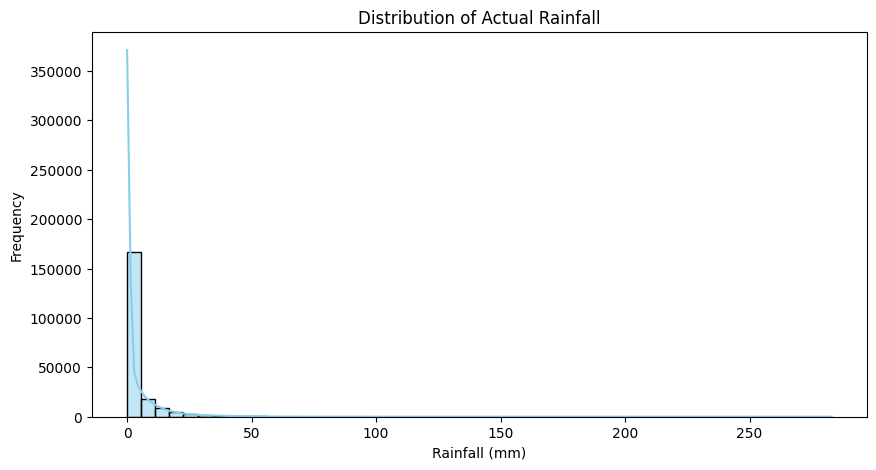

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df['actual'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Actual Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

## Time Series Plot of Rainfall

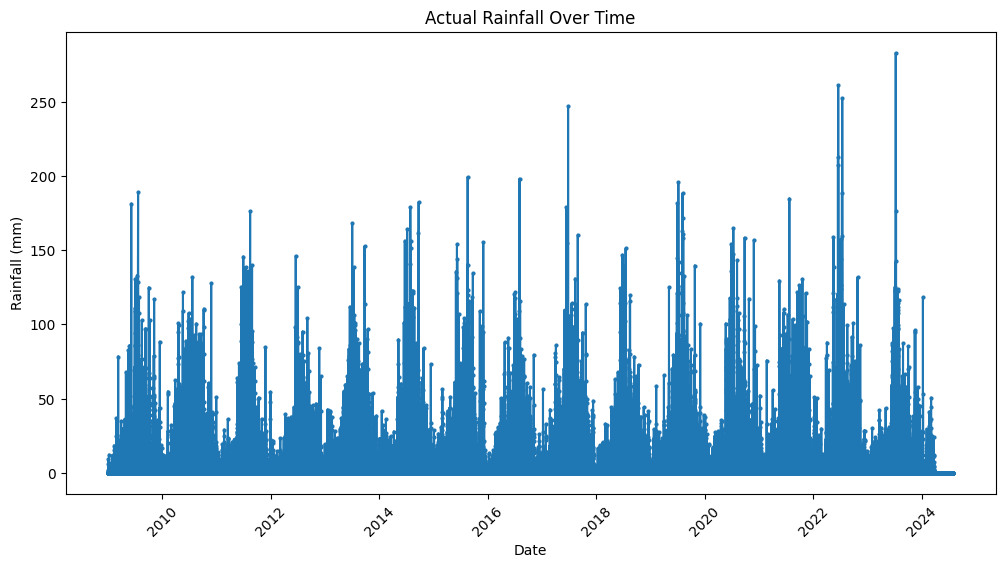

In [28]:
df['date'] = pd.to_datetime(df['date'])
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['actual'], marker='o', linestyle='-', markersize=2)
plt.title("Actual Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=45)
plt.show()

## Correlation Heatmap

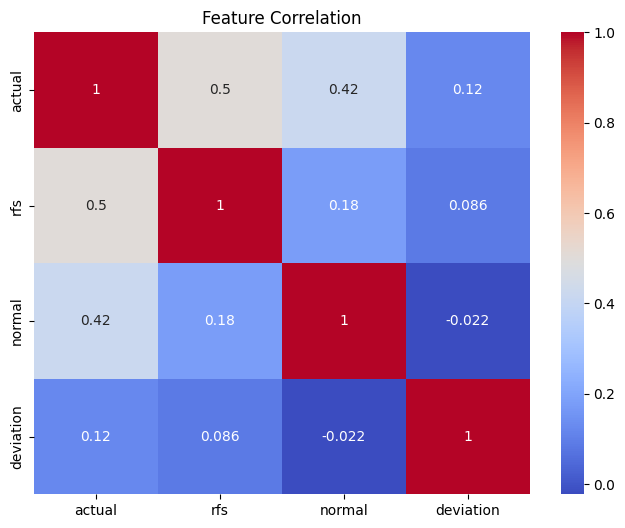

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['actual', 'rfs', 'normal', 'deviation']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## Scatter Plot: Actual vs RFS

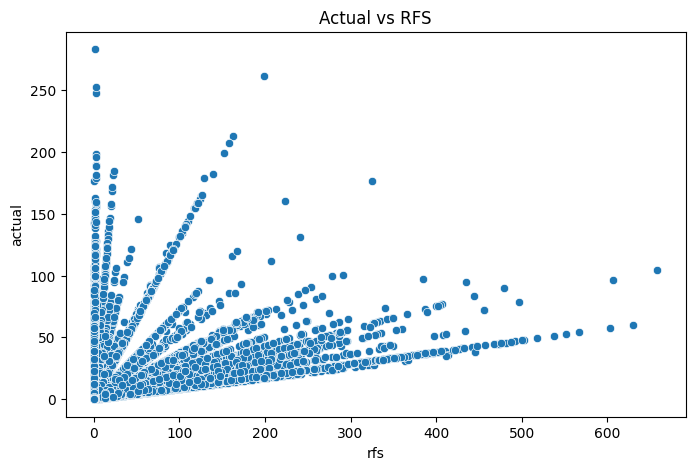

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='rfs', y='actual', data=df)
plt.title("Actual vs RFS")
plt.show()